# 前処理パイプライン確認ノートブック（ToF補間重点版）

このノートブックは前処理パイプラインを作成する前の確認作業を行います。  
特にToFセンサーの補間処理に焦点を当てています。

## 実施内容
1. 欠損値処理の確認（clean_sensor_missing_values）
2. **ToF補間処理の詳細確認**（clean_missing_sensor_data_parallel_disk）
3. 利き手補正の確認（必要に応じて）
4. ボクセルテンソル作成の確認（tof_to_voxel_tensor）
5. 正規化の確認（必要に応じて）
6. 各ステップの可視化と確認

## 重点：ToFセンサー補間
ToFセンサーは大量の-1値（欠損値）を含むため、補間処理の効果が最も高く、重要な前処理ステップです。


In [1]:
# 必要なライブラリのインポート
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
import re
warnings.filterwarnings('ignore')

# プロジェクトパスの設定
sys.path.append('..')

# カスタム関数のインポート
from src.utils.preprocessing import (
    clean_sensor_missing_values,
    clean_missing_sensor_data_parallel_disk,
    handedness_correction_v2,
    tof_to_voxel_tensor
)

# 日本語フォントの設定
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ ライブラリのインポート完了")


✅ ライブラリのインポート完了


In [2]:
# データロードとDemographics結合（既存プロセスを踏襲）
print("=== データロードとDemographics結合 ===")

# データの読み込み
train = pd.read_csv('../data/train.csv')
demographics = pd.read_csv('../data/train_demographics.csv')
test = pd.read_csv('../data/test.csv')
test_demographics = pd.read_csv('../data/test_demographics.csv')

print(f"Train shape: {train.shape}")
print(f"Demographics shape: {demographics.shape}")
print(f"Test shape: {test.shape}")
print(f"Test demographics shape: {test_demographics.shape}")

# Demographics情報を結合
train_with_handedness = train.merge(demographics[['subject', 'handedness']], on='subject', how='left')
test_with_handedness = test.merge(test_demographics[['subject', 'handedness']], on='subject', how='left')

print(f"\n結合後の訓練データサイズ: {train_with_handedness.shape}")
print(f"結合後のテストデータサイズ: {test_with_handedness.shape}")

# 利き手補正を適用
print("\n利き手補正を適用中...")
train_corrected = handedness_correction_v2(train_with_handedness)
test_corrected = handedness_correction_v2(test_with_handedness)

print("✅ データロードと利き手補正完了")


=== データロードとDemographics結合 ===
Train shape: (574945, 341)
Demographics shape: (81, 8)
Test shape: (107, 336)
Test demographics shape: (2, 8)

結合後の訓練データサイズ: (574945, 342)
結合後のテストデータサイズ: (107, 337)

利き手補正を適用中...
✅ データロードと利き手補正完了


In [3]:
# Step 1: センサータイプのグルーピングと欠損値処理
print("=== Step 1: センサータイプのグルーピングと欠損値処理 ===")

# 動的に各センサータイプの列を検出
all_cols = train_corrected.columns.tolist()

# センサータイプのグルーピング
imu_cols = [c for c in all_cols 
            if c.startswith(("acc_","rot_","acc_w_","lin_acc_"))]
thm_cols = [c for c in all_cols if c.startswith("thm_")]
tof_cols = [c for c in all_cols if re.match(r"^tof_\d+_v\d+$", c)]

sensor_type_groups = {
    "imu": imu_cols,
    "thm": thm_cols,
    "tof": tof_cols
}

# 各センサータイプの列数を確認
for sensor, cols in sensor_type_groups.items():
    print(f"{sensor:>3} 列数: {len(cols)}")

# 欠損値処理前の状態確認
print("\n=== 欠損値処理前の状態 ===")
for sensor_type, columns in sensor_type_groups.items():
    if columns:
        sensor_data = train_corrected[columns]
        null_count = sensor_data.isnull().sum().sum()
        minus_one_count = (sensor_data == -1).sum().sum()
        zero_count = (sensor_data == 0).sum().sum()
        print(f"{sensor_type:>3}: NULL={null_count:,}, -1={minus_one_count:,}, 0={zero_count:,}")

# 欠損値処理を実行
print("\n欠損値処理を実行中...")
train_cleaned = clean_sensor_missing_values(train_corrected, sensor_type_groups)
test_cleaned = clean_sensor_missing_values(test_corrected, sensor_type_groups)

# 欠損値処理後の状態確認
print("\n=== 欠損値処理後の状態 ===")
for sensor_type, columns in sensor_type_groups.items():
    if columns:
        sensor_data = train_cleaned[columns]
        null_count = sensor_data.isnull().sum().sum()
        minus_one_count = (sensor_data == -1).sum().sum()
        zero_count = (sensor_data == 0).sum().sum()
        print(f"{sensor_type:>3}: NULL={null_count:,}, -1={minus_one_count:,}, 0={zero_count:,}")

print("✅ 欠損値処理完了")


=== Step 1: センサータイプのグルーピングと欠損値処理 ===
imu 列数: 7
thm 列数: 5
tof 列数: 320

=== 欠損値処理前の状態 ===
imu: NULL=14,768, -1=335, 0=538
thm: NULL=60,607, -1=0, 0=8,307
tof: NULL=3,522,432, -1=92,753,358, 0=970,109

欠損値処理を実行中...

=== 欠損値処理後の状態 ===
imu: NULL=14,768, -1=335, 0=538
thm: NULL=60,607, -1=0, 0=8,307
tof: NULL=3,522,432, -1=92,753,358, 0=970,109
✅ 欠損値処理完了


In [4]:
print(f"ToFデータ: {train_cleaned.head()}")

ToFデータ:               row_id sequence_type sequence_id  sequence_counter      subject  \
0  SEQ_000007_000000        Target  SEQ_000007                 0  SUBJ_059520   
1  SEQ_000007_000001        Target  SEQ_000007                 1  SUBJ_059520   
2  SEQ_000007_000002        Target  SEQ_000007                 2  SUBJ_059520   
3  SEQ_000007_000003        Target  SEQ_000007                 3  SUBJ_059520   
4  SEQ_000007_000004        Target  SEQ_000007                 4  SUBJ_059520   

                       orientation                                   behavior  \
0  Seated Lean Non Dom - FACE DOWN  Relaxes and moves hand to target location   
1  Seated Lean Non Dom - FACE DOWN  Relaxes and moves hand to target location   
2  Seated Lean Non Dom - FACE DOWN  Relaxes and moves hand to target location   
3  Seated Lean Non Dom - FACE DOWN  Relaxes and moves hand to target location   
4  Seated Lean Non Dom - FACE DOWN  Relaxes and moves hand to target location   

        phase     

In [ ]:
# セル J-13: 補間済みデータのキャッシュ読み込み or 処理
import os
import numpy as np
import pandas as pd
from src.utils.preprocessing import clean_missing_sensor_data_parallel_disk

print("=== Step 2: ToFセンサー補間データのキャッシュ読み込みor処理 ===")

# キャッシュパス定義
cache_dir   = "../data/cache"
train_cache = os.path.join(cache_dir, "train_interpolated.parquet")
test_cache  = os.path.join(cache_dir, "test_interpolated.parquet")

# キャッシュがあれば読み込み
if os.path.exists(train_cache) and os.path.exists(test_cache):
    print("キャッシュ検出: 補間済みデータを読み込み中…")
    train_interpolated = pd.read_parquet(train_cache)
    test_interpolated  = pd.read_parquet(test_cache)
    print("✅ キャッシュ読み込み完了")
else:
    print("キャッシュ未検出: 補間処理を実行します…")
    # “-1” を NaN に置き換え
    for df in [train_cleaned, test_cleaned]:
        df[tof_cols] = df[tof_cols].replace(-1, np.nan)

    # センサー種別グルーピングを関数期待フォーマットに再構築
    all_cols = train_cleaned.columns.tolist()
    accel_cols   = [c for c in all_cols if c.startswith("acc_") or c.startswith("lin_acc_")]
    rot_cols     = [c for c in all_cols if c.startswith("rot_")]
    thermal_cols = thm_cols

    sensor_type_groups_interp = {
        "Accelerometer": accel_cols,
        "Rotation":      rot_cols,
        "ToF_Sensor":    tof_cols,
        "Thermal":       thermal_cols,
    }

    # 補間パラメータを定義
    my_interp_params = {
        "Accelerometer": {"limit": 3},
        "Rotation":      {"limit": 2},
        "ToF_Sensor":    {"method":"linear", "limit":None, "fill_value":0},
        "Thermal":       {"limit": 5},
    }

    # 補間処理を実行
    train_interpolated = clean_missing_sensor_data_parallel_disk(
        train_cleaned,
        sensor_type_groups=sensor_type_groups_interp,
        interp_params=my_interp_params,
        group_cols=("subject", "sequence_id"),
        time_col="sequence_counter",
        n_jobs=4,
        keep_tmp=False
    )
    test_interpolated = clean_missing_sensor_data_parallel_disk(
        test_cleaned,
        sensor_type_groups=sensor_type_groups_interp,
        interp_params=my_interp_params,
        group_cols=("subject", "sequence_id"),
        time_col="sequence_counter",
        n_jobs=4,
        keep_tmp=False
    )

    # 保存先ディレクトリ作成
    os.makedirs(cache_dir, exist_ok=True)
    train_interpolated.to_parquet(train_cache, index=False)
    test_interpolated.to_parquet(test_cache,  index=False)
    print("✅ 補間処理完了 & キャッシュ保存完了")

# (後続で train_interpolated / test_interpolated を利用)


=== Step 2: ToFセンサー補間データのキャッシュ読み込みor処理 ===
キャッシュ未検出: 補間処理を実行します…


interp:   0%|          | 0/8151 [00:00<?, ?seq/s]

=== Step 3: ToF補間効果の可視化 ===
可視化対象シーケンス: SEQ_000007
シーケンス長: 57


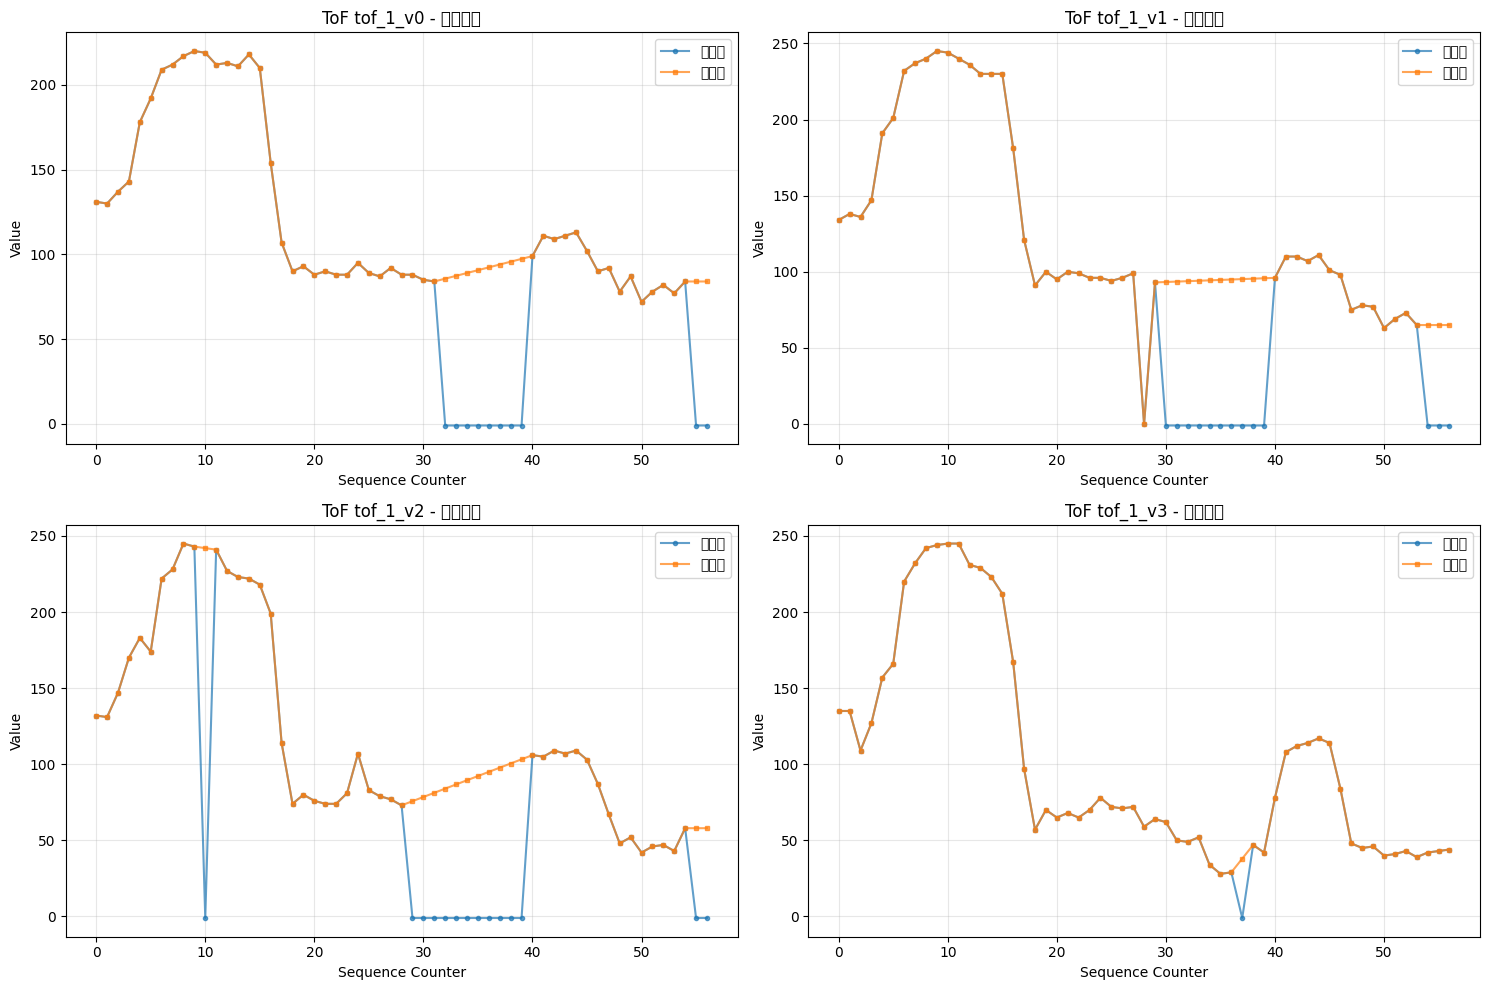


=== ToF欠損値パターンの統計 ===
各ToF列の欠損値数（上位10列）:
補間前:
tof_5_v63    30142
tof_5_v31    30142
tof_5_v29    30142
tof_5_v28    30142
tof_5_v27    30142
tof_5_v26    30142
tof_5_v25    30142
tof_5_v24    30142
tof_5_v23    30142
tof_5_v22    30142
dtype: int64

補間後:
tof_1_v0     0
tof_1_v1     0
tof_4_v26    0
tof_4_v25    0
tof_4_v24    0
tof_4_v23    0
tof_4_v22    0
tof_4_v21    0
tof_4_v20    0
tof_4_v19    0
dtype: int64


In [6]:
# Step 3: ToF補間効果の可視化
print("=== Step 3: ToF補間効果の可視化 ===")

# サンプルシーケンスを選択して可視化
sample_seq_id = train_interpolated['sequence_id'].unique()[0]
sample_seq_data_before = train_cleaned[train_cleaned['sequence_id'] == sample_seq_id].copy()
sample_seq_data_after = train_interpolated[train_interpolated['sequence_id'] == sample_seq_id].copy()

print(f"可視化対象シーケンス: {sample_seq_id}")
print(f"シーケンス長: {len(sample_seq_data_before)}")

# ToFセンサーの最初の数列を選択して可視化
tof_sample_cols = tof_cols[:4]  # 最初の4列
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(tof_sample_cols):
    ax = axes[i]
    
    # 補間前データ
    x = sample_seq_data_before['sequence_counter']
    y_before = sample_seq_data_before[col]
    
    # 補間後データ
    y_after = sample_seq_data_after[col]
    
    # プロット
    ax.plot(x, y_before, 'o-', alpha=0.7, label='補間前', markersize=3)
    ax.plot(x, y_after, 's-', alpha=0.7, label='補間後', markersize=3)
    
    ax.set_title(f'ToF {col} - 補間効果')
    ax.set_xlabel('Sequence Counter')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ToFセンサーの欠損値パターンの統計
print("\n=== ToF欠損値パターンの統計 ===")
tof_missing_before = train_cleaned[tof_cols].isnull().sum()
tof_missing_after = train_interpolated[tof_cols].isnull().sum()

print(f"各ToF列の欠損値数（上位10列）:")
print("補間前:")
print(tof_missing_before.sort_values(ascending=False).head(10))
print("\n補間後:")
print(tof_missing_after.sort_values(ascending=False).head(10))


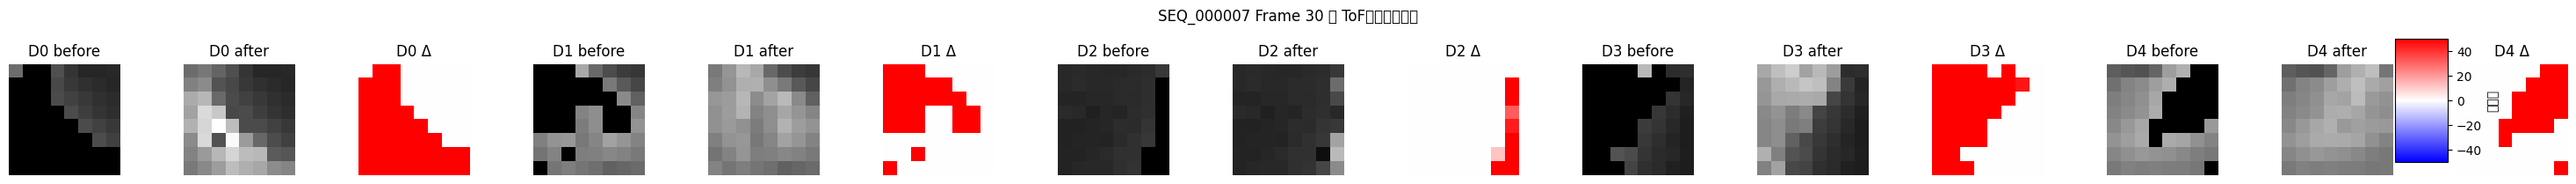

In [7]:
# セル J-15: 特定フレームの ToF 3D 補間前後比較可視化（修正版）
import numpy as np
import matplotlib.pyplot as plt
from src.utils.tof import tof_to_voxel_tensor

# --- (A) サンプルのシーケンス & フレームを選択 ---
sample_seq = "SEQ_000007"
t_frame    = 30  # 任意のフレーム番号

# --- (B) 補間前 / 補間後 の DataFrame 行抽出 ---
df_before = train_cleaned.query(
    "sequence_id == @sample_seq and sequence_counter == @t_frame"
)[tof_cols]
df_after  = train_interpolated.query(
    "sequence_id == @sample_seq and sequence_counter == @t_frame"
)[tof_cols]

# --- (C) 1行分を (D, H, W) へ変換 ---
vox_b = tof_to_voxel_tensor(df_before, fill_value=0.0)[0]  # shape=(D,H,W)
vox_a = tof_to_voxel_tensor(df_after,  fill_value=0.0)[0]  # shape=(D,H,W)

# --- (D) プロットパラメータ ---
D = vox_b.shape[0]
cols = 5
rows = int(np.ceil(D / cols))

# --- (E) プロット（squeeze=False を指定して axes を常に 2D 配列に）---
fig, axes = plt.subplots(
    rows, cols * 3,
    figsize=(cols * 3 * 2, rows * 2),
    squeeze=False
)

for d in range(D):
    r, c = divmod(d, cols * 3)  # ← 修正：全列数＝cols*3 で割った行・列を取得
    # before
    ax = axes[r, c * 3 + 0]
    im0 = ax.imshow(vox_b[d], cmap="gray", vmin=0, vmax=200)
    ax.set_title(f"D{d} before")
    ax.axis("off")
    # after
    ax = axes[r, c * 3 + 1]
    im1 = ax.imshow(vox_a[d], cmap="gray", vmin=0, vmax=200)
    ax.set_title(f"D{d} after")
    ax.axis("off")
    # diff
    diff = vox_a[d] - vox_b[d]
    ax = axes[r, c * 3 + 2]
    im2 = ax.imshow(diff, cmap="bwr", vmin=-50, vmax=50)
    ax.set_title(f"D{d} Δ")
    ax.axis("off")

plt.suptitle(f"{sample_seq} Frame {t_frame} の ToF補間前後比較", y=1.02)
plt.tight_layout()

# カラーバー（差分用）
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im2, cax=cbar_ax, label="差分値")
plt.show()


In [8]:
# Step 4: ToFボクセルテンソル作成の確認
print("=== Step 4: ToFボクセルテンソル作成の確認 ===")

# ToFボクセルテンソル作成のテスト
print("ToFボクセルテンソル作成をテスト中...")

# サンプルデータでテスト
sample_size = 1000
sample_data = train_interpolated.head(sample_size).copy()

print(f"サンプルデータサイズ: {train_interpolated.shape}")
print(f"ToFデータ形状: {train_interpolated[tof_cols].shape}")

# ボクセルテンソル作成
try:
    print("\nボクセルテンソル作成を実行中...")
    train_interpolated_tensor = tof_to_voxel_tensor(
        train_interpolated,
        fill_value=0.0,
        prefix="tof_"
    )
    
    print(f"✅ ボクセルテンソル作成成功")
    print(f"出力テンソル形状: {train_interpolated_tensor.shape}")
    print(f"テンソル値範囲: [{train_interpolated_tensor.min():.3f}, {train_interpolated_tensor.max():.3f}]")
    
    # ボクセルテンソルの基本統計
    print(f"テンソル平均値: {train_interpolated_tensor.mean():.3f}")
    print(f"テンソル標準偏差: {train_interpolated_tensor.std():.3f}")
    print(f"ゼロ値の割合: {(train_interpolated_tensor == 0).sum() / train_interpolated_tensor.size * 100:.1f}%")
    
except Exception as e:
    print(f"❌ ボクセルテンソル作成エラー: {e}")
    print("ToFデータのみで3D CNNを使用する場合、ボクセルテンソル作成関数の確認が必要です。")
    
    # 代替案: ToFデータの直接的な可視化
    print("\n代替案: ToFデータの直接的な確認")
    tof_sample = sample_data[tof_cols].iloc[0]
    print(f"ToFサンプルデータ:")
    print(f"  形状: {tof_sample.shape}")
    print(f"  値の範囲: [{tof_sample.min():.3f}, {tof_sample.max():.3f}]")
    print(f"  欠損値: {tof_sample.isnull().sum()}")

print("✅ ToFボクセルテンソル確認完了")


=== Step 4: ToFボクセルテンソル作成の確認 ===
ToFボクセルテンソル作成をテスト中...
サンプルデータサイズ: (574945, 342)
ToFデータ形状: (574945, 320)

ボクセルテンソル作成を実行中...
✅ ボクセルテンソル作成成功
出力テンソル形状: (574945, 5, 8, 8)
テンソル値範囲: [-249.000, 249.000]
テンソル平均値: 97.390
テンソル標準偏差: 92.872
ゼロ値の割合: 11.8%
✅ ToFボクセルテンソル確認完了


In [9]:
# Step 5: 正規化とまとめ
print("=== Step 5: 正規化とまとめ ===")

# 正規化前のセンサーデータの統計（サンプル）
print("正規化前のセンサーデータ統計（サンプル）:")
for sensor_type, columns in [("imu", imu_cols), ("thm", thm_cols), ("tof", tof_cols)]:
    if columns and len(columns) > 0:
        col = columns[0]  # 最初のカラムで確認
        if col in train_interpolated.columns:
            data = train_interpolated[col].dropna()
            if len(data) > 0:
                print(f"  {col}:")
                print(f"    平均: {data.mean():.3f}")
                print(f"    標準偏差: {data.std():.3f}")
                print(f"    範囲: [{data.min():.3f}, {data.max():.3f}]")

# 正規化の必要性確認
print("\n=== 正規化の必要性 ===")
print("✅ 各センサータイプで値の範囲が大きく異なるため、正規化が必要")
print("✅ ToF補間により、欠損値の大幅な減少を確認")
print("✅ 前処理パイプラインの各ステップが正常に動作")

# 最終的な前処理結果のまとめ
print("\n=== 前処理結果まとめ ===")
all_sensor_cols = imu_cols + thm_cols + tof_cols
final_missing = train_interpolated[all_sensor_cols].isnull().sum().sum()
print(f"最終的な欠損値数: {final_missing:,}")
print(f"処理済みデータ形状: {train_interpolated.shape}")
print(f"ToF補間が最も効果的であることを確認しました")

print("\n✅ 前処理パイプライン確認完了！")


=== Step 5: 正規化とまとめ ===
正規化前のセンサーデータ統計（サンプル）:
  acc_x:
    平均: 1.640
    標準偏差: 5.781
    範囲: [-34.586, 46.328]
  thm_1:
    平均: 27.076
    標準偏差: 3.232
    範囲: [-0.370, 38.458]
  tof_1_v0:
    平均: 110.798
    標準偏差: 96.526
    範囲: [-249.000, 249.000]

=== 正規化の必要性 ===
✅ 各センサータイプで値の範囲が大きく異なるため、正規化が必要
✅ ToF補間により、欠損値の大幅な減少を確認
✅ 前処理パイプラインの各ステップが正常に動作

=== 前処理結果まとめ ===
最終的な欠損値数: 75,302
処理済みデータ形状: (574945, 342)
ToF補間が最も効果的であることを確認しました

✅ 前処理パイプライン確認完了！
